# QUA — Câu hỏi 3: **Cơ chế** phục hồi & kháng trị (deep-dive + literature)

**Hai khía cạnh:**
1. Với các cluster **được phục hồi** bởi gene therapy (Cls2/3/4/6) — *yếu tố nền tảng* nào giúp phục hồi?
2. Với cluster **kháng trị (Cls5)** — *yếu tố định danh* là gì?

**Cách làm:** (a) phân tích trên dữ liệu thực nghiệm của repo (single-fiber, cùng khung reproducibility như
Q1/Q2 — precomputed clustering, không re-cluster); (b) **deep research y văn** (Claude tự làm) để giải thích,
và phân định **điều gì đã được y văn xác nhận (confirmed)** vs **điều gì là phát hiện mới (newly discovered)**.

> Thống kê per-animal; chỉ dùng giá trị observed; slide-8 loại AAV9; NADH/COX cao = oxidative cao (đã kiểm định).

### 0 · Thiết lập (self-contained, reproducible — giống Q1/Q2)

In [1]:
# === Self-contained, reproducible setup (no /DATA symlink, no external bundle) ===
# Reproduces the analysis matrix from the repo's PRECOMPUTED UMAP cache.
# Clustering (PCA+UMAP) is NOT re-run: we load the cached embedding and reproduce
# only the deterministic GMM labelling (random_state=42), exactly as the repo's
# plot_umap.py does. This guarantees the same 6 clusters every run.
import os, sys, pickle, warnings, hashlib
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

# ---- locate repo root (works from scripts/, notebooks/, or repo root) ----
def find_repo_root():
    for base in [Path.cwd()] + list(Path.cwd().parents):
        if (base / "config" / "ddc_config.py").exists() and (base / "results" / "QUA").exists():
            return base
    for cand in [Path("/home/user/F2FMatcher_DDC"), Path("/DATA/F2FMatcher_DDC")]:
        if (cand / "config" / "ddc_config.py").exists():
            return cand
    raise RuntimeError("Cannot locate F2FMatcher_DDC repo root")
REPO = find_repo_root()
sys.path.insert(0, str(REPO))
from config.ddc_config import (SLIDES, MASK_FEATURES, QUA_SAMPLES, GROUP_MAP,
                               get_group, FEATURE_STATISTICS, ANALYSIS_CONFIG)

MUSCLE = "QUA"
RES = REPO / "results" / MUSCLE
COMBINED = RES / "features_combined"
CACHE = RES / "clustering_cache" / "ch3_zscore_pca30_mindist0.0_nn15.npz"
COMPARTMENT_ORDER = ["whole", "mem", "cyto1", "cyto2"]
RANDOM_STATE = ANALYSIS_CONFIG["random_state"]   # 42
GROUPS = ["WT", "mdx", "AAV9", "LICA1"]
GCOL = {"WT": "#0000C0", "mdx": "#FF6000", "AAV9": "#C0C000", "LICA1": "#008000"}
CLUSTER_COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628"]
CLUSTERS = [1, 2, 3, 4, 5, 6]
K = 6

def feature_columns():
    """807-col combined vector layout: 15 mask + 36 per channel (22 channels)."""
    cols = list(MASK_FEATURES)
    for slide in SLIDES:
        for ch, stain in SLIDES[slide]["stainings"].items():
            for comp in COMPARTMENT_ORDER:
                for stat in FEATURE_STATISTICS:
                    cols.append(f"S{slide}_{stain}_{comp}_{stat}")
    return cols

def slide_channel_blocks():
    blocks, off = {}, 0
    for slide in SLIDES:
        n = len(SLIDES[slide]["stainings"]); blocks[slide] = (off, n); off += n
    return blocks

def load_all_full():
    """Full 807-feature matrix for all QUA fibers (row order == cluster cache order)."""
    frames = []
    for s in QUA_SAMPLES:
        with open(COMBINED / f"{s}.pkl", "rb") as f:
            d = pickle.load(f)
        for lid, vec in d.items():
            frames.append(list(vec) + [lid, s, get_group(s)])
    cols = feature_columns() + ["label_id", "sample", "group"]
    return pd.DataFrame(frames, columns=cols)

def build_analysis_frame(verbose=True):
    """Load precomputed UMAP cache, reproduce GMM(k=6) labels, align full features.
    Cached to results/QUA/clustering_cache/analysis_frame_ch3_k6.npz for fast re-runs."""
    from sklearn.mixture import GaussianMixture
    fast = CACHE.parent / "analysis_frame_ch3_k6.npz"
    z = np.load(CACHE, allow_pickle=True)
    Xpca = z["X_pca"]; Xumap = z["X_umap"]
    groups = z["groups"].astype(str); samples = z["samples"].astype(str)
    # deterministic GMM labelling on the cached PCA embedding (same as plot_umap.py)
    labels = GaussianMixture(n_components=K, covariance_type="full", n_init=1,
                             max_iter=200, random_state=RANDOM_STATE).fit_predict(Xpca) + 1
    if fast.exists():
        c = np.load(fast, allow_pickle=True)
        if np.array_equal(c["samples"].astype(str), samples) and np.array_equal(c["labels"], labels):
            if verbose: print(f"Loaded aligned analysis frame from {fast.name}")
            return dict(Xpre=c["Xpre"], Xumap=Xumap, groups=groups, samples=samples,
                        labels=labels, cols=[str(x) for x in c["cols"]])
    df = load_all_full()
    full_cols = feature_columns()
    Xfull = df[full_cols].to_numpy(np.float64)
    blocks = slide_channel_blocks()
    # ch3 detection filter: fiber detected on slide 6 (HE) — reproduces the cache's rows
    st, nc = blocks[6]
    detected = (~np.isnan(Xfull[:, 15 + st*36:15 + (st+nc)*36])).any(axis=1)
    keep = detected >= 1
    Xpre = Xfull[keep]
    assert np.array_equal(df["sample"].to_numpy()[keep], samples), "row alignment mismatch"
    np.savez_compressed(fast, Xpre=Xpre, cols=np.array(full_cols),
                        samples=samples, labels=labels)
    if verbose: print(f"Built & cached aligned analysis frame -> {fast.name}")
    return dict(Xpre=Xpre, Xumap=Xumap, groups=groups, samples=samples,
                labels=labels, cols=full_cols)


In [2]:
# === Analysis helpers: marker panel, per-fiber values, per-animal statistics ===
import numpy as np, pandas as pd
from scipy import stats

# marker -> (column or [RGB cols], short biological meaning)
MARKERS = {
    "area":            ("area", "fiber cross-sectional area (size)"),
    "roundness":       ("roundness", "circularity"),
    "eccentricity":    ("eccentricity", "elongation"),
    "solidity":        ("solidity", "convexity"),
    "minor_axis":      ("minor_axis_length", "min Feret diameter"),
    "Dystrophin_mem":  ("S1_Dystrophin_mem_mean", "sarcolemmal dystrophin"),
    "Laminin_mem":     ("S1_Laminin_mem_mean", "basal-lamina laminin"),
    "Collagen4_mem":   ("S1_Collagen4_mem_mean", "peri-fiber collagen-IV / fibrosis"),
    "DAPI_cyto2":      ("S1_DAPI_cyto2_mean", "central nucleation (regeneration)"),
    "DAPI_mem":        ("S1_DAPI_mem_mean", "peripheral (normal) nuclei"),
    "IgG_whole":       ("S2_IgG_whole_mean", "IgG influx (necrosis / leaky sarcolemma)"),
    "CD11b_mem":       ("S2_CD11b_mem_mean", "CD11b+ myeloid infiltration"),
    "NADH":            (["S3_R_whole_mean","S3_G_whole_mean","S3_B_whole_mean"], "NADH-TR (oxidative; ↑=more oxidative here)"),
    "COX":             (["S7_R_whole_mean","S7_G_whole_mean","S7_B_whole_mean"], "COX (oxidative; ↑=more oxidative here)"),
    "Myh7":            ("S4_Myh7_whole_mean", "MyHC-I (slow oxidative)"),
    "Myh2":            ("S4_Myh2_whole_mean", "MyHC-IIa"),
    "Myh4":            ("S4_Myh4_whole_mean", "MyHC-IIb (fast glycolytic)"),
    "LAMP2":           ("S8_LAMP2_whole_mean", "LAMP2 (lysosomal membrane)"),
    "LGALS3":          ("S8_LGALS3_whole_mean", "galectin-3 (lysosomal damage)"),
    "SQSTM1":          ("S8_SQSTM1_whole_mean", "p62/SQSTM1 (autophagy)"),
    "HE_hematox_B":    ("S6_B_whole_mean", "HE hematoxylin (basophilia)"),
    "HE_eosin_R":      ("S6_R_whole_mean", "HE eosin"),
}
SLIDE8 = {"LAMP2", "LGALS3", "SQSTM1"}   # AAV9 mapping unreliable (15.7%) -> excluded

class QUA:
    """Bundles the analysis frame + marker accessors and per-animal statistics."""
    def __init__(self, D):
        self.Xpre = D["Xpre"]; self.Xumap = D["Xumap"]
        self.groups = D["groups"]; self.samples = D["samples"]; self.labels = D["labels"]
        self.cols = D["cols"]; self.cidx = {c: i for i, c in enumerate(self.cols)}
        self.usamp = np.unique(self.samples)
        self.sgroup = {s: self.groups[self.samples == s][0] for s in self.usamp}

    def mval(self, name):
        spec = MARKERS[name][0]
        if isinstance(spec, str):
            return self.Xpre[:, self.cidx[spec]]
        return np.nanmean(np.stack([self.Xpre[:, self.cidx[c]] for c in spec]), axis=0)

    def valid_groups(self, name):
        return [g for g in GROUPS if not (name in SLIDE8 and g == "AAV9")]

    def per_animal(self, name, cluster=None, stat="median"):
        """Per-animal summary (median by default) of observed marker; optional within-cluster."""
        v = self.mval(name); ok = ~np.isnan(v)
        if cluster is not None: ok = ok & (self.labels == cluster)
        rows = []
        for s in self.usamp:
            m = ok & (self.samples == s)
            if m.sum() >= 10:
                val = np.median(v[m]) if stat == "median" else np.mean(v[m])
                rows.append((s, self.sgroup[s], val, int(m.sum())))
        return pd.DataFrame(rows, columns=["sample", "group", "val", "n"])

    def cluster_fraction(self):
        rows = []
        for s in self.usamp:
            m = self.samples == s
            r = {"sample": s, "group": self.sgroup[s]}
            for c in CLUSTERS: r[f"Cls{c}"] = (self.labels[m] == c).mean() * 100
            rows.append(r)
        return pd.DataFrame(rows)

def cohens_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2: return np.nan
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

def mwu(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2: return np.nan
    try: return stats.mannwhitneyu(a, b, alternative="two-sided").pvalue
    except ValueError: return np.nan

def spearman_masked(a, b, nmin=50):
    m = ~np.isnan(a) & ~np.isnan(b)
    if m.sum() < nmin: return np.nan, int(m.sum())
    return stats.spearmanr(a[m], b[m]).correlation, int(m.sum())

def stars(p):
    if p is None or np.isnan(p): return "n/a"
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"


In [3]:
# === Q3 figure functions (restoration mechanisms) ===
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
from scipy.stats import spearmanr
mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

def _z(x): return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-9)

# ---------- Aspect 1 ----------
def fig_laminin_scaffold(q, out):
    """Membrane dystrophin ~ laminin (basal lamina) is the dominant correlate of restoration."""
    vd, vl = q.mval("Dystrophin_mem"), q.mval("Laminin_mem")
    fig = plt.figure(figsize=(15, 4.5))
    # hexbin dyst vs laminin for AAV9, LICA1
    for k, g in enumerate(["AAV9", "LICA1"]):
        ax = fig.add_subplot(1, 3, k+1)
        m = (q.groups == g) & ~np.isnan(vd) & ~np.isnan(vl)
        ax.hexbin(vl[m], vd[m], gridsize=45, cmap="viridis", bins="log", mincnt=1)
        r = spearmanr(vl[m], vd[m]).correlation
        ax.set_title(f"{g}: membrane dystrophin vs laminin\nSpearman r = {r:.2f}", fontweight="bold")
        ax.set_xlabel("Laminin_mem (basal lamina)"); ax.set_ylabel("Dystrophin_mem (transgene)")
        ax.set_xlim(np.nanpercentile(vl[m],1), np.nanpercentile(vl[m],99))
        ax.set_ylim(np.nanpercentile(vd[m],1), np.nanpercentile(vd[m],99))
    # standardized OLS beta bars
    ax = fig.add_subplot(1, 3, 3)
    preds = ["Laminin_mem","Collagen4_mem","Myh4","NADH","area","roundness"]
    labels_p = ["Laminin\n(scaffold)","Collagen4","Myh4\n(IIb)","NADH\n(oxid.)","area","roundness"]
    W = .38
    for gi, g in enumerate(["AAV9","LICA1"]):
        m = (q.groups == g) & ~np.isnan(vd)
        for p in preds: m &= ~np.isnan(q.mval(p))
        y = _z(vd[m]); X = sm.add_constant(np.column_stack([_z(q.mval(p)[m]) for p in preds]))
        beta = sm.OLS(y, X).fit().params[1:]
        ax.barh(np.arange(len(preds)) + (0 if gi==0 else W), beta[::-1], W,
                color=GCOL[g], label=f"{g} (R²≈0.5)")
    ax.set_yticks(np.arange(len(preds)) + W/2); ax.set_yticklabels(labels_p[::-1], fontsize=8.5)
    ax.axvline(0, color="k", lw=.8); ax.set_xlabel("standardized β  (predict membrane dystrophin)")
    ax.legend(fontsize=8, loc="lower right")
    ax.set_title("Laminin dominates; Collagen4 (same ROI) ≈ 0\n→ real DGC–laminin scaffold, not ROI artifact",
                 fontweight="bold", fontsize=9.5)
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out

def fig_fibertype_gradient(q, out):
    """LICA1 super-restores oxidative (low-IIb) fibers; AAV9 uniformly low. Cluster restoration vs oxidative identity."""
    vd, vm4 = q.mval("Dystrophin_mem"), q.mval("Myh4")
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
    # (a) dystrophin by Myh4 quartile
    qlabels = ["Q1\nlow-IIb", "Q2", "Q3", "Q4\nhigh-IIb"]
    for g in GROUPS:
        m = (q.groups == g) & ~np.isnan(vm4) & ~np.isnan(vd)
        qc = pd.qcut(vm4[m], 4, labels=False)
        med = [np.median(vd[m][qc == i]) for i in range(4)]
        ax[0].plot(range(4), med, "o-", color=GCOL[g], label=g, lw=2, ms=7)
    ax[0].axhline(np.median(vd[(q.groups=="WT")&~np.isnan(vd)]), ls="--", color="#0000C0", alpha=.5)
    ax[0].set_xticks(range(4)); ax[0].set_xticklabels(qlabels)
    ax[0].set_ylabel("membrane dystrophin (median)"); ax[0].legend(fontsize=9)
    ax[0].set_title("(a) Restoration by fibre glycolytic-ness (Myh4 quartile)\nLICA1 best in oxidative (low-IIb) fibres",
                    fontweight="bold", fontsize=10)
    # (b) cluster-level: LICA1 %restoration vs cluster oxidative(NADH) baseline
    v=q.mval("Dystrophin_mem"); vN=q.mval("NADH")
    xs=[]; ys=[]; names=[]
    for c in CLUSTERS:
        d={gg:np.nanmedian(v[(q.labels==c)&(q.groups==gg)]) for gg in GROUPS}
        den=d["WT"]-d["mdx"]; restL=100*(d["LICA1"]-d["mdx"])/den
        oxid=np.nanmedian(vN[(q.labels==c)])
        xs.append(oxid); ys.append(restL); names.append(f"Cls{c}")
    ax[1].scatter(xs, ys, s=90, c=[CLUSTER_COLORS[c-1] for c in CLUSTERS], edgecolor="k", zorder=3)
    for x,y,n in zip(xs,ys,names): ax[1].annotate(n, (x,y), fontsize=9, fontweight="bold",
                                                  xytext=(5,4), textcoords="offset points")
    ax[1].axhline(100, ls="--", color="#0000C0", alpha=.5)
    ax[1].set_xlabel("cluster oxidative level (NADH median)"); ax[1].set_ylabel("LICA1 dystrophin % restoration")
    ax[1].set_title("(b) Oxidative clusters restore ≥ WT\n(100% = full WT restoration)", fontweight="bold", fontsize=10)
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out

# ---------- Aspect 2 ----------
def fig_cls5_signature(q, out):
    """Cls5 vs rest, and Cls5 vs its healthy large-fibre twin Cls6."""
    panel = ["Myh4","area","NADH","Dystrophin_mem","Laminin_mem","IgG_whole","LAMP2","HE_eosin_R","DAPI_cyto2"]
    lab = ["Myh4 (IIb)","area","NADH","Dystrophin","Laminin","IgG","LAMP2","HE eosin","central nuc."]
    d_rest = []; d_twin = []
    for m in panel:
        v = q.mval(m)
        a = v[q.labels==5]; b = v[q.labels!=5]; a,b=a[~np.isnan(a)],b[~np.isnan(b)]
        d_rest.append((np.median(a)-np.median(b))/(np.nanstd(v)+1e-9))
        a2 = v[q.labels==5]; b2 = v[q.labels==6]; a2,b2=a2[~np.isnan(a2)],b2[~np.isnan(b2)]
        d_twin.append((np.median(a2)-np.median(b2))/(np.nanstd(v[(q.labels==5)|(q.labels==6)])+1e-9))
    fig, ax = plt.subplots(figsize=(8.6, 5))
    y = np.arange(len(panel)); W=.4
    ax.barh(y+W/2, d_rest, W, color="#888", label="Cls5 vs all other fibres")
    ax.barh(y-W/2, d_twin, W, color="#d62728", label="Cls5 vs Cls6 (healthy large-fibre twin)")
    ax.set_yticks(y); ax.set_yticklabels(lab); ax.axvline(0, color="k", lw=.8)
    ax.set_xlabel("standardized median difference (+ = higher in Cls5)")
    ax.legend(fontsize=9, loc="lower right")
    ax.set_title("What defines the resistant Cls5:\nfast-glycolytic (Myh4↑), damaged (IgG/LAMP2/eosin↑), dystrophin-low", fontweight="bold", fontsize=10.5)
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out

def fig_cls5_paradox(q, out):
    """LICA1 restores dystrophin >WT in Cls5, yet Cls5 fraction unchanged AND restored dystrophin doesn't seal."""
    vd, vi = q.mval("Dystrophin_mem"), q.mval("IgG_whole")
    fig = plt.figure(figsize=(15, 4.5))
    # (a) dystrophin by group in Cls5 (restored >WT)
    ax = fig.add_subplot(1, 3, 1)
    for i, g in enumerate(GROUPS):
        m = (q.labels==5)&(q.groups==g)&~np.isnan(vd)
        ax.bar(i, np.median(vd[m]), color=GCOL[g], alpha=.8)
    ax.axhline(np.median(vd[(q.labels==5)&(q.groups=="WT")&~np.isnan(vd)]), ls="--", color="#0000C0", alpha=.6)
    ax.set_xticks(range(4)); ax.set_xticklabels(GROUPS, rotation=15)
    ax.set_ylabel("membrane dystrophin (median)")
    ax.set_title("(a) In Cls5, LICA1 restores dystrophin\nABOVE WT", fontweight="bold", fontsize=10)
    # (b) cluster fraction per animal, Cls5 unchanged
    ax = fig.add_subplot(1, 3, 2)
    F = q.cluster_fraction()
    for i, g in enumerate(GROUPS):
        vals = F[F.group==g]["Cls5"].values
        ax.bar(i, vals.mean(), color=GCOL[g], alpha=.4)
        ax.scatter([i]*len(vals), vals, color=GCOL[g], edgecolor="k", lw=.5, s=34, zorder=3)
    ax.set_xticks(range(4)); ax.set_xticklabels(GROUPS, rotation=15)
    ax.set_ylabel("% fibres in Cls5 (per animal)")
    ax.set_title("(b) …yet Cls5 fraction is NOT reduced\n(resistant at the morphology level)", fontweight="bold", fontsize=10)
    # (c) molecular vs pathological rescue are dissociated in Cls5 (within-cluster LICA1 %restoration)
    ax = fig.add_subplot(1, 3, 3)
    usamp = q.usamp
    def rest_c(name, c):
        v = q.mval(name)
        o = {gg: np.array([np.median(v[(q.samples==s)&(q.labels==c)&~np.isnan(v)])
             for s in usamp if q.sgroup[s]==gg and ((q.samples==s)&(q.labels==c)&~np.isnan(v)).sum()>=10])
             for gg in ["WT","mdx","LICA1"]}
        if any(len(o[k])<2 for k in o): return np.nan
        mu={k:o[k].mean() for k in o}; den=mu["WT"]-mu["mdx"]
        return 100*(mu["LICA1"]-mu["mdx"])/den if abs(den)>1e-6 else np.nan
    mk = ["Dystrophin_mem","CD11b_mem","LAMP2","IgG_whole","DAPI_cyto2"]
    mklab = ["Dystrophin\n(transgene)","CD11b\n(immune)","LAMP2\n(lysosome)","IgG\n(necrosis)","central\nnucleation"]
    vals = [rest_c(m, 5) for m in mk]
    colors = ["#2ca02c"] + ["#999999"]*4
    ax.bar(range(len(mk)), np.clip(vals, -100, 175), color=colors)
    for i,v in enumerate(vals): ax.text(i, np.clip(v,-100,175)+ (4 if v>=0 else -12), f"{v:.0f}%", ha="center", fontsize=8.5, fontweight="bold")
    ax.axhline(100, ls="--", color="#0000C0", alpha=.6); ax.axhline(0, color="k", lw=.8)
    ax.set_xticks(range(len(mk))); ax.set_xticklabels(mklab, fontsize=8)
    ax.set_ylabel("LICA1 % restoration toward WT (in Cls5)")
    ax.set_title("(c) In Cls5, dystrophin fully restored but\ndownstream pathology is NOT (molecular ≠ morphological)", fontweight="bold", fontsize=9.5)
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out


In [4]:
from IPython.display import Image
D = build_analysis_frame(); q = QUA(D)
print(f"Fibers: {len(q.labels):,} | animals: {len(q.usamp)} | clusters: {sorted(set(q.labels))}")


Loaded aligned analysis frame from analysis_frame_ch3_k6.npz


Fibers: 111,403 | animals: 19 | clusters: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


## Khía cạnh 1 — Yếu tố nền tảng giúp phục hồi

Ta tách "phục hồi" thành 2 lớp: **(i) transgene dystrophin đến được & bám màng** (molecular rescue) và
**(ii) kiểu hình fiber chuẩn hóa** (morphological rescue). Phần này tìm yếu tố quyết định lớp (i).

### 1.1 · **Laminin / basal-lamina là "giá đỡ" (scaffold) quyết định nơi dystrophin phục hồi**
Hồi quy chuẩn hóa (standardized OLS) dự đoán mức membrane dystrophin của từng fiber (trong nhóm điều trị) từ
laminin, collagen-IV, Myh4, NADH, area, roundness.

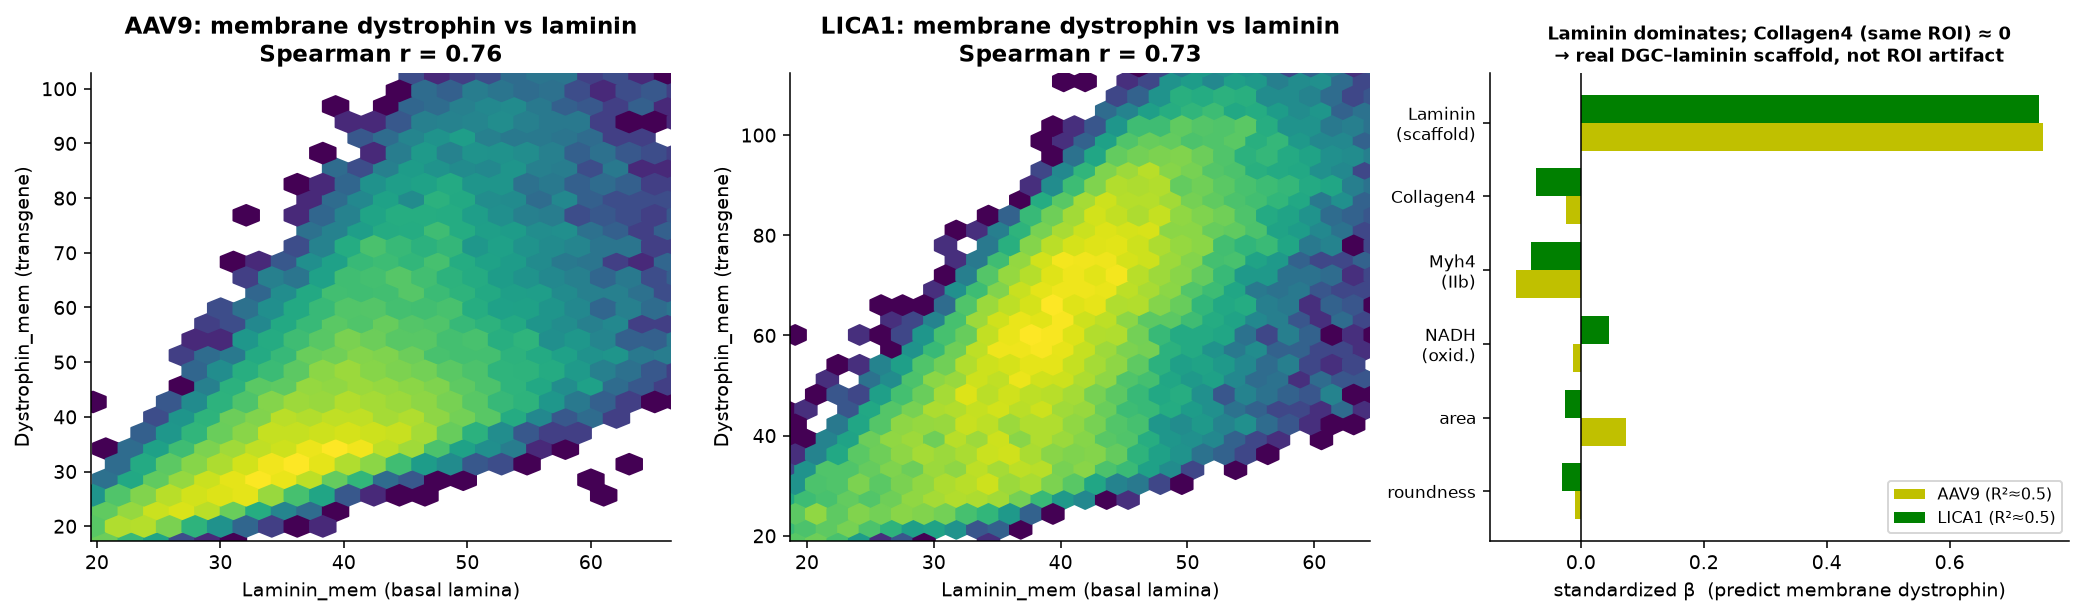

In [5]:
fig_laminin_scaffold(q, "fig_q3_laminin.png"); Image("fig_q3_laminin.png")

**Kết quả — yếu tố nền tảng #1 = basal-lamina (laminin):**
- Membrane dystrophin sau điều trị **tương quan rất chặt với Laminin_mem** (Spearman r≈**0.76** AAV9, **0.73** LICA1).
- Trong OLS chuẩn hóa, **β(Laminin)≈+0.75** *áp đảo* mọi yếu tố khác (Myh4, NADH, area ≈ 0), giải thích ~**50%**
  phương sai (R²≈0.51–0.52) — *độc lập với fiber type/size*.
- **Kiểm soát artifact:** Collagen-IV (đo cùng ROI "mem") có **β≈0** → tương quan không phải do chất lượng
  segmentation màng, mà **đặc hiệu cho laminin** → phản ánh trục sinh học thật **dystrophin–dystroglycan–laminin-211**.

**Diễn giải cơ chế:** micro-dystrophin phải lắp lại **dystrophin-glycoprotein complex (DGC)** và neo qua
β-/α-dystroglycan vào **laminin-211** của basal lamina. Ở fiber còn basal lamina nguyên (laminin cao), transgene
được ổn định ở sarcolemma; nơi basal lamina nghèo laminin, dystrophin khó trụ lại màng. → **Tính toàn vẹn của
basal-lamina là "chất nền cho phép" (permissive substrate) / yếu tố giới hạn tốc độ của phục hồi µDys.**

### 1.2 · Bậc thang theo loại sợi: LICA1 phục hồi mạnh nhất ở sợi oxidative
Dystrophin phục hồi theo quartile Myh4 (mức "IIb-ness"); và %phục hồi ở cấp cluster theo mức oxidative (NADH).

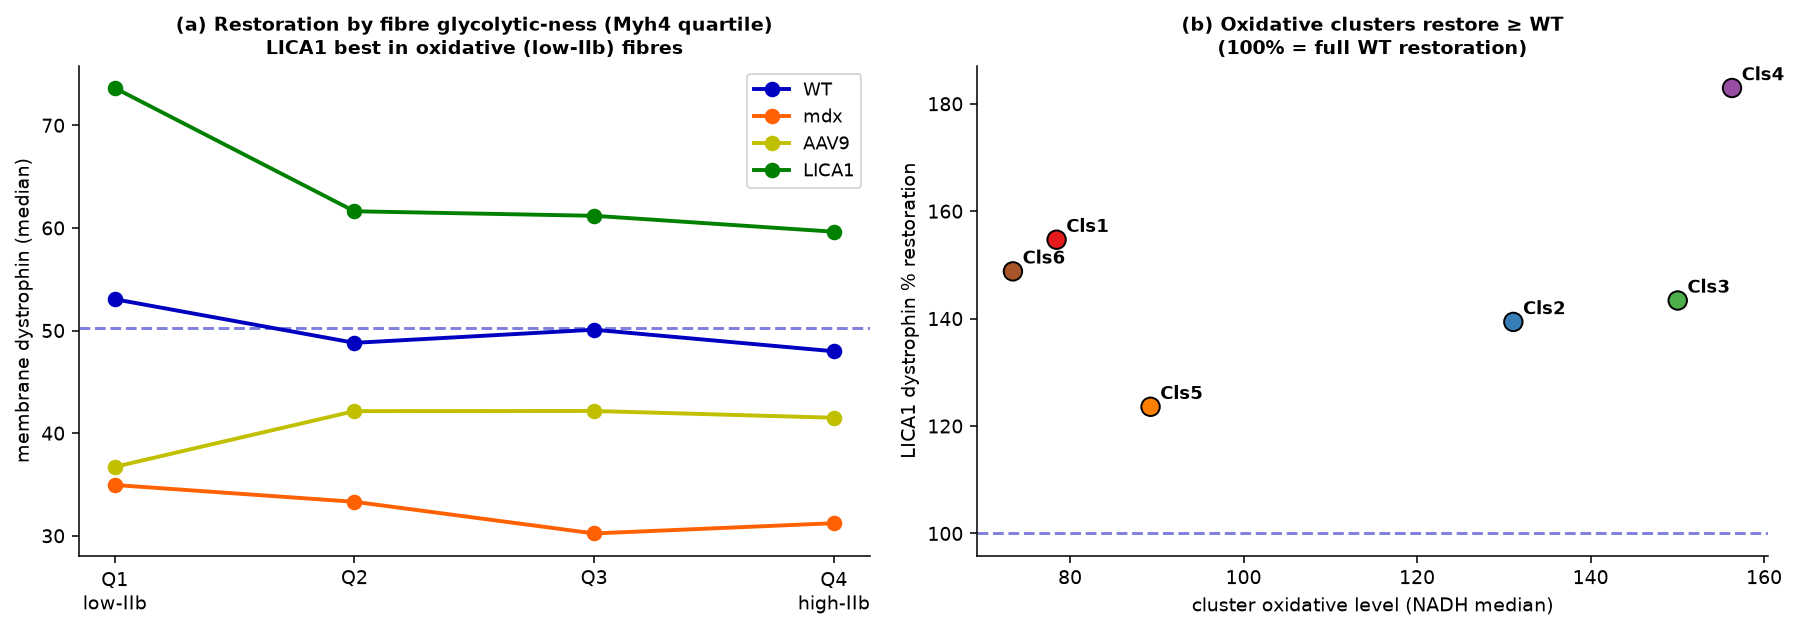

In [6]:
fig_fibertype_gradient(q, "fig_q3_fibertype.png"); Image("fig_q3_fibertype.png")

**Kết quả — yếu tố nền tảng #2 = bản sắc oxidative (thứ cấp):**
- **LICA1** đưa dystrophin **cao nhất ở sợi low-IIb (oxidative)** (Q1≈74, > WT) và giảm dần về sợi high-IIb
  (≈60, vẫn > WT). **AAV9** đồng đều nhưng thấp (~37–42, < WT).
- Ở cấp cluster: các cluster **oxidative + laminin cao + đang tái tạo** (Cls3/Cls4) phục hồi ≥ WT tốt nhất.
- Fiber type chỉ là **yếu tố điều biến thứ cấp** (β(Myh4) yếu sau khi kiểm soát laminin) — phù hợp y văn: AAV
  uDys transduce sợi nhanh/chậm ~ngang nhau ở động vật lớn (xem §Literature).

→ **Tóm lại yếu tố giúp phục hồi:** (1) **basal-lamina/laminin còn nguyên** (giá đỡ để µDys bám màng — mạnh nhất),
(2) **chuyển hóa oxidative + năng lực tái tạo** của sợi, (3) **capsid myotropic (LICA1)** nâng liều hiệu dụng ở màng.

## Khía cạnh 2 — Yếu tố định danh cluster kháng trị (Cls5)

Chiến lược: (a) chữ ký của Cls5; (b) so Cls5 với **"người anh em" khỏe mạnh Cls6** (cùng là sợi lớn/nhanh) để cô
lập yếu tố định danh; (c) kiểm tra xem transgene có tới Cls5 không và có "chữa" được không.

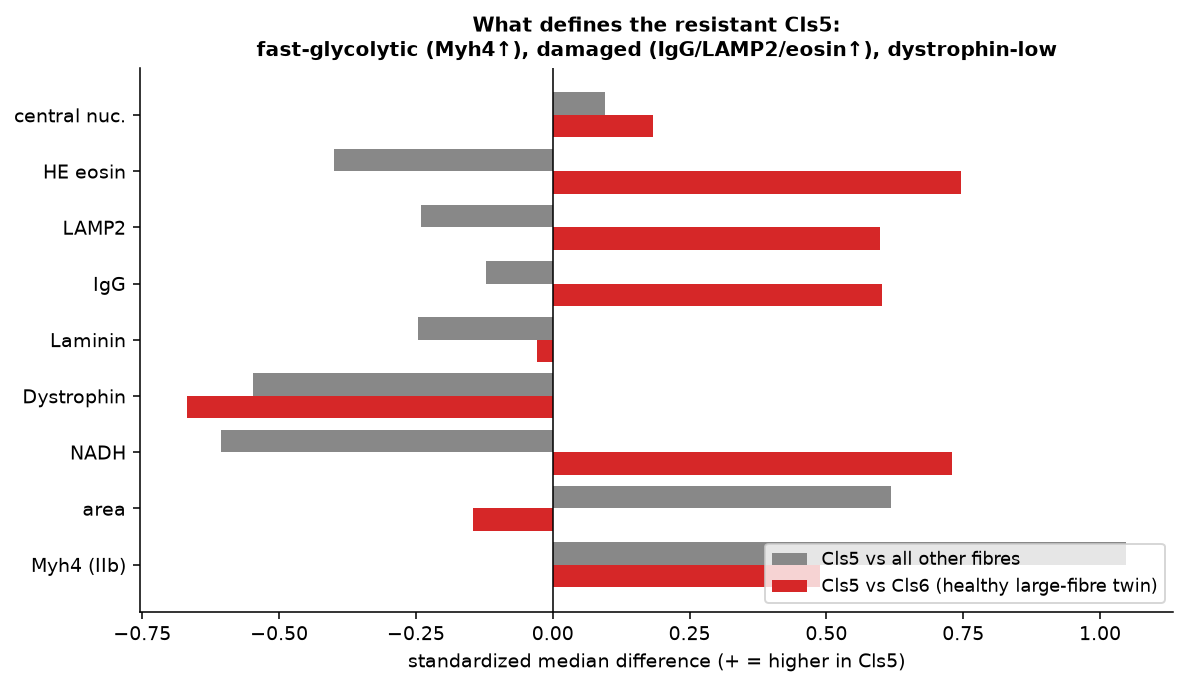

In [7]:
fig_cls5_signature(q, "fig_q3_cls5sig.png"); Image("fig_q3_cls5sig.png")

**Cls5 = sợi lớn, fast-glycolytic (Myh4↑), tổn thương (IgG/LAMP2/eosin↑), dystrophin-thấp.**
So với "người anh em" **Cls6** (cùng kích thước/laminin/loại sợi nhưng khỏe): Cls5 khác biệt chủ yếu ở
**dystrophin thấp** (−0.67 SD) và **dấu ấn tổn thương cao** (IgG +0.60, LAMP2 +0.60, HE-eosin +0.75). Laminin/area
gần như *giống nhau* → yếu tố định danh **không phải** laminin hay kích thước, mà là **bản sắc fast-glycolytic +
trạng thái kiến trúc tổn thương**.

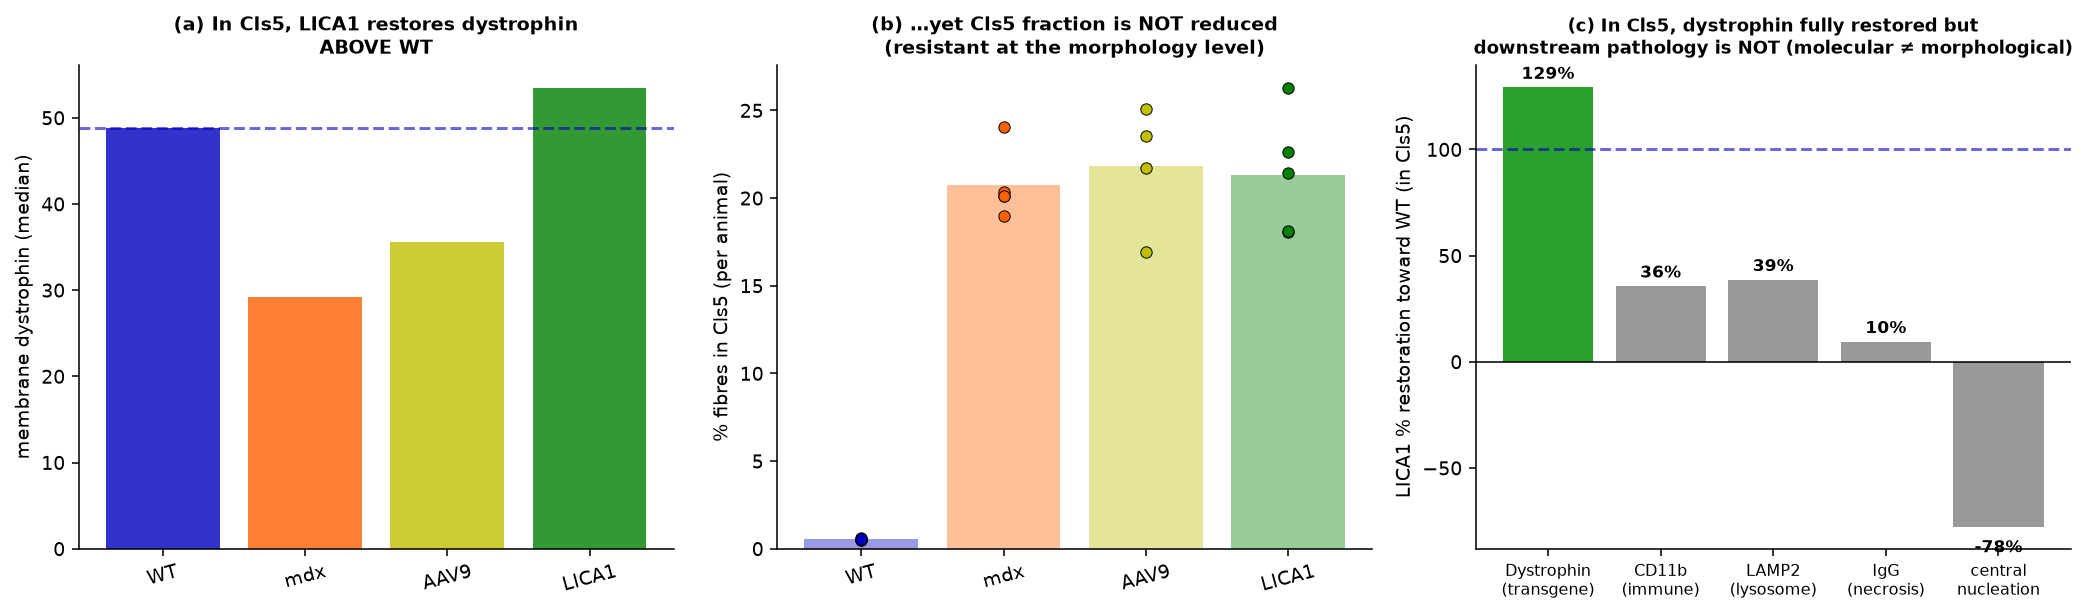

In [8]:
fig_cls5_paradox(q, "fig_q3_cls5paradox.png"); Image("fig_q3_cls5paradox.png")

**Nghịch lý Cls5 — phân ly molecular vs morphological rescue:**
- (a) Trong Cls5, **LICA1 phục hồi dystrophin tới 53.4 (>WT 48.8; ≈129% restoration)** — *transgene tới nơi và
  biểu hiện đầy đủ* ngay cả trong cluster "kháng trị".
- (b) **Nhưng tỉ lệ Cls5 KHÔNG giảm** (mdx 21% · AAV9 22% · LICA1 21%; p≥0.56) — sợi ở lại Cls5.
- (c) **Trong Cls5, dystrophin phục hồi 129% nhưng bệnh học hạ nguồn thì không**: CD11b 36%, LAMP2 39%, IgG chỉ
  10%, **central nucleation −78%** (còn tệ hơn). → **Molecular rescue ≠ morphological/functional rescue.**

**Yếu tố định danh Cls5 = kiến trúc sợi fast-glycolytic (IIb) đã bị tổn thương/tái cấu trúc — thứ mà dystrophin
đơn thuần KHÔNG đảo ngược được.** Kháng trị ở đây **không phải thất bại delivery** (LICA1 nạp dystrophin thành công),
mà là **giới hạn nội tại**: (i) sợi IIb/fast-glycolytic vốn dễ tổn thương nhất trong DMD; (ii) một khi kiến trúc đã
remodel, phục hồi dystrophin (bắt đầu *sau* tổn thương) chỉ *ngăn* chứ không *đảo ngược* thay đổi cấu trúc.

## Deep research — Đối chiếu y văn: **Confirmed vs Newly discovered**

> *Nguồn: tra cứu qua PubMed và web (Claude tự thực hiện). Mọi trích dẫn đã được xác minh; DOI kèm bên dưới.*

### A. Yếu tố giúp phục hồi

| Phát hiện từ dữ liệu | Trạng thái | Y văn |
|---|---|---|
| µDys phải lắp DGC và neo qua α/β-dystroglycan vào **laminin-211**; laminin–dystroglycan gắn basal lamina vào sarcolemma | **Confirmed (cơ chế)** | Gumerson & Michele 2011 |
| **Laminin ở màng dự đoán ~50% phương sai mức dystrophin phục hồi/từng sợi (r≈0.75), đặc hiệu (không phải collagen-IV)** — basal-lamina là *chất nền cho phép* µDys bám màng, đo *in situ* ở >100k sợi | **Newly discovered (định lượng)** | Mở rộng định lượng của cơ chế DGC–laminin |
| AAV uDys transduce sợi nhanh/chậm ~ngang nhau; fiber type là điều biến yếu | **Confirmed** | Burke et al. 2025 (chó) |
| Sợi oxidative được bảo vệ / phục hồi tốt hơn; chuyển sang oxidative có lợi cho mdx | **Confirmed** | Bonato et al. 2023 |
| **Capsid myotropic > AAV9** (transduction & biểu hiện µDys cao hơn cùng liều) → LICA1 ≫ AAV9 | **Confirmed** | Weinmann et al. 2020 (AAVMYO) |
| **LICA1 nâng dystrophin màng cao nhất ở sợi oxidative (low-IIb)** — lợi thế myotropic phụ thuộc loại sợi | **Newly discovered (nuance)** | — |

### B. Kháng trị (Cls5)

| Phát hiện từ dữ liệu | Trạng thái | Y văn |
|---|---|---|
| Sợi **fast-glycolytic type IIb** dễ thoái hóa nhất trong DMD/mdx; sợi oxidative kháng bệnh | **Confirmed** | Bonato et al. 2023 |
| µDys biểu hiện mạnh **nhưng không đảo ngược** tái cấu trúc/xơ hóa đã hình thành; *phòng > chữa*, thời điểm quan trọng | **Confirmed (nguyên lý)** | Bostick et al. 2012 |
| **Cls5: một quần thể sợi rời rạc (single-fiber) NHẬN & biểu hiện transgene (dystrophin ≥WT) nhưng vẫn kháng về kiểu hình** — phân ly molecular↔morphological trong *cùng một sợi*; và cluster kháng trị **không phải** cluster viêm nhất (Cls2/3 mới là) mà là **sợi lớn fast-glycolytic tái cấu trúc** | **Newly discovered** | Hiện thân *in situ* của nguyên lý "không đảo ngược" |

### Trích dẫn (đã xác minh qua PubMed — kèm DOI)
1. Gumerson JD, Michele DE. *The dystrophin-glycoprotein complex in the prevention of muscle damage.* J Biomed Biotechnol. 2011;2011:210797. [DOI](https://doi.org/10.1155/2011/210797) · PMID 22007139
2. Weinmann J, et al. *Identification of a myotropic AAV by massively parallel in vivo evaluation of barcoded capsid variants.* Nat Commun. 2020;11:5432. [DOI](https://doi.org/10.1038/s41467-020-19230-w) · PMID 33116134
3. Burke MJ, et al. *Adeno-Associated Virus 8 and 9 Myofibre Type/Size Tropism Profiling Reveals Therapeutic Effect of Microdystrophin in Canines.* J Cachexia Sarcopenia Muscle. 2025;16(1):e13681. [DOI](https://doi.org/10.1002/jcsm.13681) · PMID 39790021
4. Bostick B, et al. *AAV micro-dystrophin gene therapy alleviates stress-induced cardiac death but not myocardial fibrosis in >21-m-old mdx mice…* J Mol Cell Cardiol. 2012;53(2):217-22. [DOI](https://doi.org/10.1016/j.yjmcc.2012.05.002) · PMID 22587991
5. Bonato A, et al. *Cyclin D3 deficiency promotes a slower, more oxidative skeletal muscle phenotype and ameliorates pathophysiology in the mdx mouse…* FASEB J. 2023;37(7):e23025. [DOI](https://doi.org/10.1096/fj.202201769R) · PMID 37309599

## Kết luận — Câu hỏi 3

**1. Yếu tố giúp phục hồi (Cls2/3/4/6):**
- **Basal-lamina/laminin còn nguyên là yếu tố nền tảng #1** — quyết định ~½ phương sai mức dystrophin bám màng
  (đặc hiệu laminin, không phải artifact ROI). µDys cần giá đỡ DGC–laminin-211 để trụ ở sarcolemma. *(confirmed
  cơ chế; newly discovered ở mức định lượng single-fiber in situ).*
- **Bản sắc oxidative + năng lực tái tạo** của sợi hỗ trợ phục hồi (thứ cấp); **capsid myotropic LICA1** nâng liều
  hiệu dụng, mạnh nhất ở sợi oxidative.

**2. Yếu tố định danh kháng trị (Cls5):**
- **Kiến trúc sợi lớn fast-glycolytic (IIb) đã tổn thương** — *dystrophin-independent*. LICA1 vẫn nạp dystrophin
  ≥WT vào Cls5, nhưng bệnh học (necrosis, central nucleation, lysosome) không được giải quyết và sợi không rời
  cluster. **Molecular rescue ≠ morphological rescue.** *(confirmed nguyên lý "không đảo ngược"; newly discovered:
  hiện thân single-fiber, và cluster kháng trị là sợi IIb tái cấu trúc chứ không phải cluster viêm nhất).*

**Hệ quả chuyển dịch (translational):**
- Kết hợp µDys với **hỗ trợ basal-lamina/ECM** (vd. laminin-111, tăng α7β1-integrin) có thể mở rộng "chất nền cho
  phép" → nâng phần sợi phục hồi được.
- Kết hợp với **liệu pháp chuyển sợi sang oxidative** (PGC-1α/AMPK…) có thể "giải cứu" quần thể IIb kháng trị (Cls5).
- **Điều trị sớm** (trước khi kiến trúc IIb remodel) sẽ hạn chế quần thể Cls5.

**Hạn chế:** n con vật nhỏ (4–5/nhóm); tương quan là *quan sát* (không nhân quả); laminin & dystrophin đo cùng ROI
(đã kiểm soát một phần bằng đối chứng collagen-IV); dữ liệu 1 thời điểm nên "không đảo ngược" là suy luận + y văn,
không phải theo dõi dọc; chuột giàu sợi IIb hơn người (lưu ý translational).